# IntelliWell Decision Support System

## Project Overview

This notebook integrates the Production Forecasting model and the Pressure Anomaly Detection model developed in the previous notebooks.

The objective is to simulate an intelligent well monitoring system capable of:

- Forecasting oil production
- Detecting pressure anomalies
- Assessing well health
- Estimating operational risk
- Generating intelligent operational recommendations

The notebook serves as the final decision support layer of the IntelliWell framework.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
# ==========================================
# Load Trained Models
# ==========================================

production_model = joblib.load("production_model.pkl")

pressure_model = joblib.load("pressure_model.pkl")

pressure_scaler = joblib.load("pressure_scaler.pkl")

production_features = joblib.load("production_features.pkl")

pressure_features = joblib.load("pressure_features.pkl")

print("Models Loaded Successfully.")

Models Loaded Successfully.


In [3]:
# ==========================================
# Load Daily Production Data
# ==========================================

df = pd.read_excel(
    "Volve production data.xlsx",
    sheet_name="Daily Production Data"
)

df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])

print(df.shape)

df.head()

(15634, 24)


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,0.00000,0.0,0.000000,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,1.003059,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.979008,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.545759,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,277.27826,0.0,1.215987,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [4]:
# ==========================================
# Date Features
# ==========================================

df["YEAR"] = df["DATEPRD"].dt.year
df["MONTH"] = df["DATEPRD"].dt.month
df["DAY"] = df["DATEPRD"].dt.day
df["DAY_OF_WEEK"] = df["DATEPRD"].dt.dayofweek

In [5]:
# ==========================================
# Production Features
# ==========================================

X_prod = df[production_features].copy()

X_prod.replace(
    [np.inf,-np.inf],
    np.nan,
    inplace=True
)

X_prod.fillna(
    X_prod.median(),
    inplace=True
)

,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_WHP_P,AVG_WHT_P,AVG_CHOKE_SIZE_P,DP_CHOKE_SIZE,YEAR,MONTH,DAY,DAY_OF_WEEK
0,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,2014,4,7,0
1,0.0,232.896939,103.186689,175.588861,0.000000,0.00000,0.00000,1.003059,0.00000,2014,4,8,1
2,0.0,232.896939,103.186689,175.588861,0.000000,0.00000,0.00000,0.979008,0.00000,2014,4,9,2
3,0.0,232.896939,103.186689,175.588861,0.000000,0.00000,0.00000,0.545759,0.00000,2014,4,10,3
4,0.0,310.376140,96.875890,277.278260,0.000000,33.09788,10.47992,1.215987,33.07195,2014,4,11,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,0.0,232.896939,103.186689,175.588861,0.272720,0.07776,0.22879,0.636088,0.01862,2016,9,14,2
15630,0.0,232.896939,103.186689,175.588861,0.286860,0.08545,0.22914,0.670794,0.00631,2016,9,15,3
15631,0.0,232.896939,103.186689,175.588861,0.286040,0.08544,0.22896,0.664393,0.01181,2016,9,16,4
15632,0.0,232.896939,103.186689,175.588861,0.272120,0.07497,0.22846,0.624660,0.02576,2016,9,17,5


In [6]:
# ==========================================
# Pressure Features
# ==========================================

X_pressure = df[pressure_features].copy()

X_pressure.replace(
    [np.inf,-np.inf],
    np.nan,
    inplace=True
)

X_pressure.fillna(
    X_pressure.median(),
    inplace=True
)

X_pressure = pressure_scaler.transform(X_pressure)

In [7]:
# ==========================================
# Production Forecast
# ==========================================

df["Predicted Production"] = production_model.predict(
    X_prod
)

df[
    [
        "BORE_OIL_VOL",
        "Predicted Production"
    ]
].head()

,BORE_OIL_VOL,Predicted Production
0,0.0,0.205983
1,0.0,0.000000
2,0.0,0.000000
3,0.0,0.000000
4,0.0,0.000000


In [8]:
# ==========================================
# Pressure Anomaly Detection
# ==========================================

df["Pressure Status"] = pressure_model.predict(
    X_pressure
)

df["Pressure Score"] = pressure_model.decision_function(
    X_pressure
)

df.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,YEAR,MONTH,DAY,DAY_OF_WEEK,Predicted Production,Pressure Status,Pressure Score
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,0.00000,0.0,0.000000,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI,2014,4,7,0,0.205983,-1,-0.016339
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,1.003059,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP,2014,4,8,1,0.000000,1,0.067227
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.979008,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP,2014,4,9,2,0.000000,1,0.073818
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.545759,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP,2014,4,10,3,0.000000,1,0.074611
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,277.27826,0.0,1.215987,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP,2014,4,11,4,0.000000,1,0.046587


# Well Health Assessment

This section combines the outputs of the production forecasting model and the pressure anomaly detection model to evaluate the operational health of each well.

The analysis includes:

- Production deviation analysis
- Pressure anomaly assessment
- Well Health Score
- Operational Risk Classification
- Intelligent operational recommendations

In [9]:
# ==========================================
# Production Deviation
# ==========================================

df["Production Deviation"] = (
    df["BORE_OIL_VOL"] -
    df["Predicted Production"]
)

df["Production Error (%)"] = (
    abs(df["Production Deviation"]) /
    (df["BORE_OIL_VOL"] + 1e-6)
) * 100

df[
    [
        "BORE_OIL_VOL",
        "Predicted Production",
        "Production Error (%)"
    ]
].head()

,BORE_OIL_VOL,Predicted Production,Production Error (%)
0,0.0,0.205983,2.059833e+07
1,0.0,0.000000,0.000000e+00
2,0.0,0.000000,0.000000e+00
3,0.0,0.000000,0.000000e+00
4,0.0,0.000000,0.000000e+00


In [10]:
# ==========================================
# Normalize Production Error
# ==========================================

production_score = 100 - np.clip(
    df["Production Error (%)"],
    0,
    100
)

df["Production Score"] = production_score

In [11]:
# ==========================================
# Normalize Pressure Score
# ==========================================

pressure_score = (
    (
        df["Pressure Score"] -
        df["Pressure Score"].min()
    )
    /
    (
        df["Pressure Score"].max() -
        df["Pressure Score"].min()
    )
)

df["Pressure Score (%)"] = pressure_score * 100

In [12]:
# ==========================================
# Well Health Score
# ==========================================

df["Well Health Score"] = (
    0.60 * df["Production Score"] +
    0.40 * df["Pressure Score (%)"]
)

df[
    [
        "Production Score",
        "Pressure Score (%)",
        "Well Health Score"
    ]
].head()

,Production Score,Pressure Score (%),Well Health Score
0,0.0,4.911624,1.964649
1,100.0,30.355927,72.142371
2,100.0,32.363000,72.945200
3,100.0,32.604475,73.041790
4,100.0,24.071567,69.628627


In [13]:
# ==========================================
# Risk Classification
# ==========================================

def classify_risk(score):

    if score >= 85:
        return "Healthy"

    elif score >= 70:
        return "Monitor"

    elif score >= 50:
        return "Warning"

    else:
        return "Critical"

df["Operational Status"] = df[
    "Well Health Score"
].apply(classify_risk)

df[
    "Operational Status"
].value_counts()

Operational Status
Critical    6813
Monitor     5599
Healthy     2200
Warning     1022
Name: count, dtype: int64

In [14]:
# ==========================================
# Intelligent Recommendation Engine
# ==========================================

def recommendation(row):

    if row["Operational Status"] == "Healthy":
        return "Continue normal operation."

    elif row["Operational Status"] == "Monitor":
        return "Increase monitoring frequency."

    elif row["Operational Status"] == "Warning":
        return "Inspect pressure system and choke settings."

    else:
        return "Immediate inspection recommended. Check tubing, pressure sensors and production equipment."

df["Recommendation"] = df.apply(
    recommendation,
    axis=1
)

df[
    [
        "Operational Status",
        "Recommendation"
    ]
].head()

,Operational Status,Recommendation
0,Critical,Immediate inspection recommended. Check tubing...
1,Monitor,Increase monitoring frequency.
2,Monitor,Increase monitoring frequency.
3,Monitor,Increase monitoring frequency.
4,Warning,Inspect pressure system and choke settings.


# Integrated Dashboard

This section presents the outputs of the forecasting and anomaly detection models in a unified dashboard to support operational decision-making.

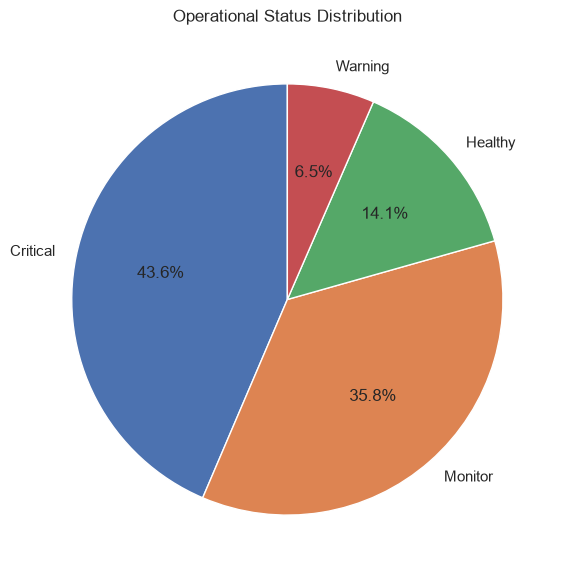

In [15]:
# ==========================================
# Operational Status Distribution
# ==========================================

plt.figure(figsize=(7,7))

df["Operational Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Operational Status Distribution")

plt.show()

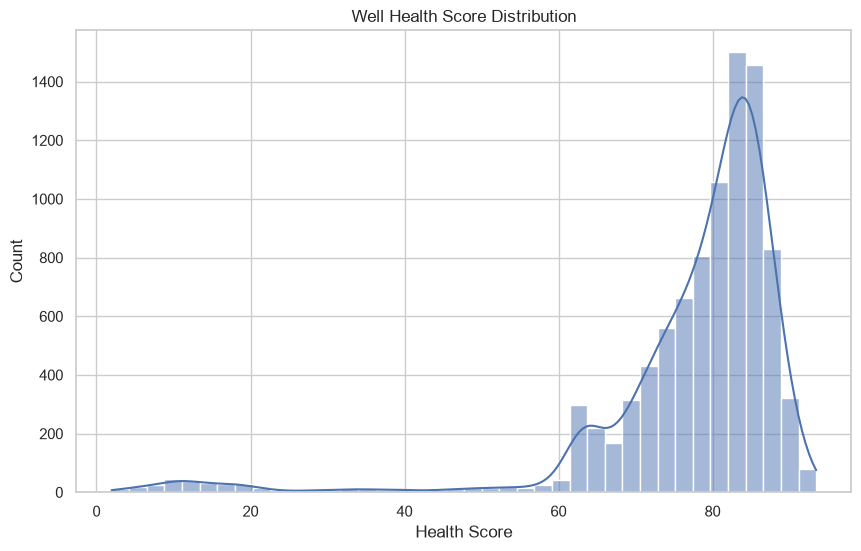

In [16]:
# ==========================================
# Well Health Score Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Well Health Score"],
    bins=40,
    kde=True
)

plt.title("Well Health Score Distribution")

plt.xlabel("Health Score")

plt.show()

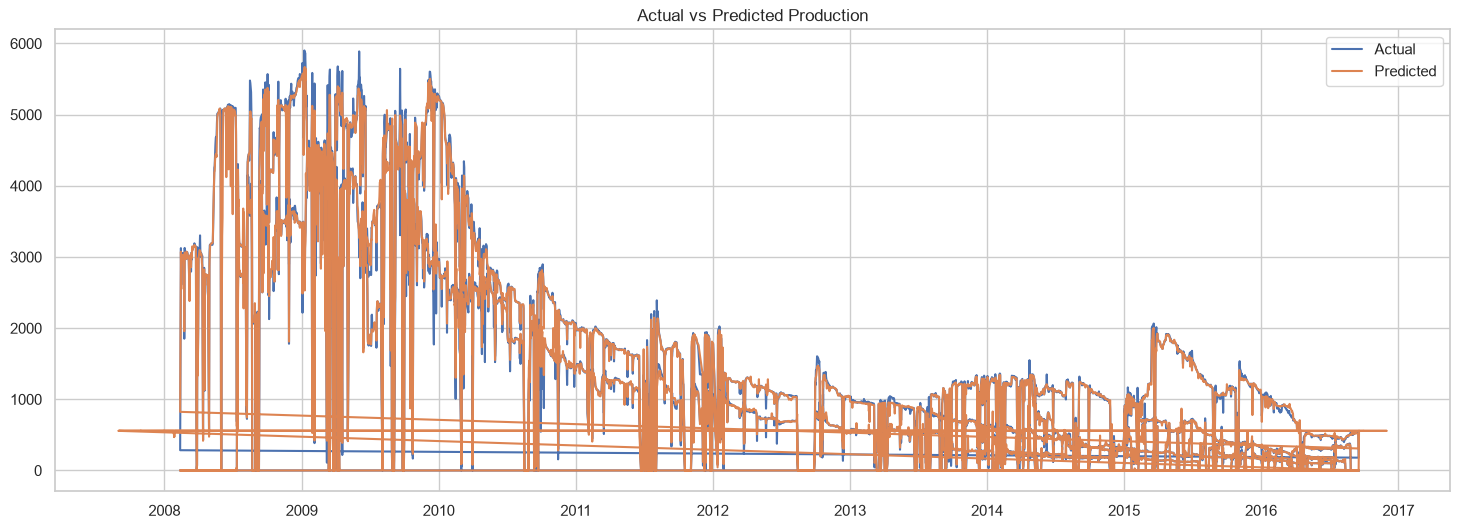

In [17]:
# ==========================================
# Forecast Comparison
# ==========================================

plt.figure(figsize=(18,6))

plt.plot(
    df["DATEPRD"],
    df["BORE_OIL_VOL"],
    label="Actual"
)

plt.plot(
    df["DATEPRD"],
    df["Predicted Production"],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Production")

plt.grid(True)

plt.show()

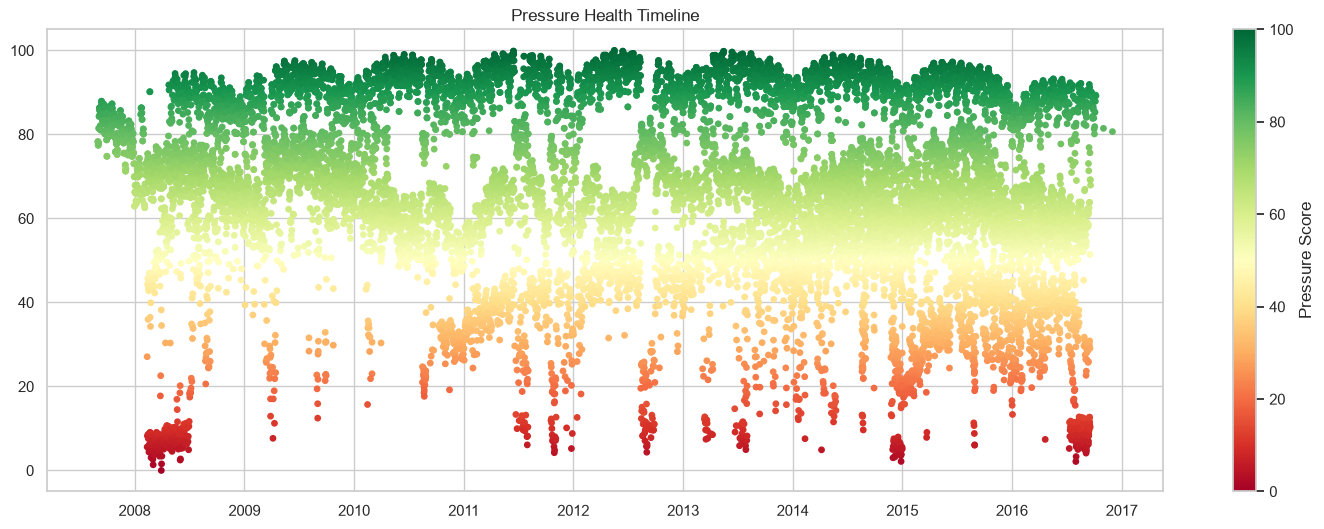

In [18]:
# ==========================================
# Pressure Score Timeline
# ==========================================

plt.figure(figsize=(18,6))

plt.scatter(
    df["DATEPRD"],
    df["Pressure Score (%)"],
    c=df["Pressure Score (%)"],
    cmap="RdYlGn",
    s=15
)

plt.colorbar(label="Pressure Score")

plt.title("Pressure Health Timeline")

plt.show()

In [19]:
# ==========================================
# Highest Risk Records
# ==========================================

highest_risk = df.sort_values(
    by="Well Health Score"
)

highest_risk[
    [
        "DATEPRD",
        "NPD_WELL_BORE_NAME",
        "BORE_OIL_VOL",
        "Predicted Production",
        "Well Health Score",
        "Operational Status"
    ]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,BORE_OIL_VOL,Predicted Production,Well Health Score,Operational Status
0,2014-04-07,15/9-F-1 C,0.00,0.205983,1.964649,Critical
5104,2008-06-29,15/9-F-14,0.00,0.720942,1.969205,Critical
4341,2015-01-01,15/9-F-12,14.94,115.768508,2.061458,Critical
746,2013-07-08,15/9-F-11,0.00,0.205983,2.355368,Critical
760,2013-07-22,15/9-F-11,0.00,0.926925,2.647612,Critical
753,2013-07-15,15/9-F-11,0.00,0.205983,2.813012,Critical
745,2016-04-21,15/9-F-1 C,0.00,0.720942,2.958087,Critical
759,2013-07-21,15/9-F-11,0.00,0.720942,3.070022,Critical
5103,2008-06-28,15/9-F-14,0.00,0.720942,3.241894,Critical
758,2013-07-20,15/9-F-11,0.00,0.720942,3.879338,Critical


In [20]:
# ==========================================
# Best Performing Records
# ==========================================

best = df.sort_values(
    by="Well Health Score",
    ascending=False
)

best[
    [
        "DATEPRD",
        "NPD_WELL_BORE_NAME",
        "Well Health Score"
    ]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,Well Health Score
2428,2009-07-16,15/9-F-12,93.452903
1481,2015-07-16,15/9-F-11,93.348988
1509,2015-08-13,15/9-F-11,93.285866
1480,2015-07-15,15/9-F-11,93.037515
1482,2015-07-17,15/9-F-11,93.011483
2427,2009-07-15,15/9-F-12,92.815236
1474,2015-07-09,15/9-F-11,92.712389
1510,2015-08-14,15/9-F-11,92.701775
1508,2015-08-12,15/9-F-11,92.685243
1487,2015-07-22,15/9-F-11,92.669183


In [21]:
# ==========================================
# Export Results
# ==========================================

df.to_csv(
    "IntelliWell_Final_Report.csv",
    index=False
)

print("Final report exported successfully.")

Final report exported successfully.


In [22]:
# ==========================================
# IntelliWell Summary
# ==========================================

print("=" * 70)
print("        INTELLIWELL DECISION SUPPORT SYSTEM")
print("=" * 70)

print(f"Dataset Size              : {len(df)}")
print(f"Average Well Health Score : {df['Well Health Score'].mean():.2f}")

print("\nOperational Status")

print(df["Operational Status"].value_counts())

print("\nModels Loaded")

print("- Random Forest Regressor")
print("- Isolation Forest")

print("\nGenerated Files")

print("- IntelliWell_Final_Report.csv")

print("=" * 70)
print("Decision Support Pipeline Completed Successfully")
print("=" * 70)

        INTELLIWELL DECISION SUPPORT SYSTEM
Dataset Size              : 15634
Average Well Health Score : 77.47

Operational Status
Operational Status
Critical    6813
Monitor     5599
Healthy     2200
Warning     1022
Name: count, dtype: int64

Models Loaded
- Random Forest Regressor
- Isolation Forest

Generated Files
- IntelliWell_Final_Report.csv
Decision Support Pipeline Completed Successfully


# Executive Dashboard

This section summarizes the operational status of the field by integrating production forecasting and pressure anomaly detection results. It provides key performance indicators (KPIs), well rankings, and actionable insights for engineers and decision-makers.

In [23]:
# ==========================================
# Executive KPIs
# ==========================================

total_records = len(df)

healthy = (df["Operational Status"]=="Healthy").sum()
monitor = (df["Operational Status"]=="Monitor").sum()
warning = (df["Operational Status"]=="Warning").sum()
critical = (df["Operational Status"]=="Critical").sum()

avg_health = df["Well Health Score"].mean()

avg_actual = df["BORE_OIL_VOL"].mean()

avg_predicted = df["Predicted Production"].mean()

pressure_anomalies = (df["Pressure Status"]==-1).sum()

print("="*60)
print("EXECUTIVE DASHBOARD")
print("="*60)

print(f"Total Records              : {total_records}")
print(f"Average Actual Production  : {avg_actual:.2f}")
print(f"Average Predicted Production : {avg_predicted:.2f}")
print(f"Average Well Health Score  : {avg_health:.2f}")

print(f"\nPressure Anomalies : {pressure_anomalies}")

print("\nOperational Status")

print(df["Operational Status"].value_counts())

print("="*60)

EXECUTIVE DASHBOARD
Total Records              : 15634
Average Actual Production  : 1095.63
Average Predicted Production : 874.46
Average Well Health Score  : 77.47

Pressure Anomalies : 313

Operational Status
Operational Status
Critical    6813
Monitor     5599
Healthy     2200
Warning     1022
Name: count, dtype: int64


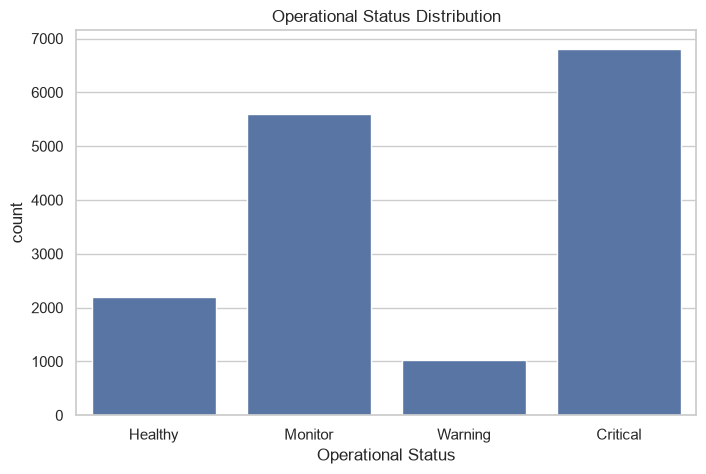

In [24]:
# ==========================================
# Operational Status
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Operational Status",
    order=[
        "Healthy",
        "Monitor",
        "Warning",
        "Critical"
    ]
)

plt.title("Operational Status Distribution")

plt.show()

In [25]:
# ==========================================
# Well Performance Summary
# ==========================================

well_summary = (

    df.groupby("NPD_WELL_BORE_NAME")

    .agg({

        "BORE_OIL_VOL":"mean",

        "Predicted Production":"mean",

        "Well Health Score":"mean",

        "Pressure Score (%)":"mean"

    })

)

well_summary.rename(columns={

    "BORE_OIL_VOL":"Actual Production",

    "Predicted Production":"Forecast Production"

}, inplace=True)

well_summary.head()

,Actual Production,Forecast Production,Well Health Score,Pressure Score (%)
NPD_WELL_BORE_NAME,,,,
15/9-F-1 C,238.216260,243.112155,75.434740,52.648190
15/9-F-11,985.278197,981.080515,80.885464,60.921061
15/9-F-12,1498.563334,1504.754588,74.210822,45.899088
15/9-F-14,1289.997837,1291.904395,80.430711,57.591078
15/9-F-15 D,151.859468,152.225876,76.022450,49.799186


In [26]:
# ==========================================
# Best Performing Wells
# ==========================================

best_wells = well_summary.sort_values(

    by="Well Health Score",

    ascending=False

)

best_wells.head(10)

,Actual Production,Forecast Production,Well Health Score,Pressure Score (%)
NPD_WELL_BORE_NAME,,,,
15/9-F-11,985.278197,981.080515,80.885464,60.921061
15/9-F-14,1289.997837,1291.904395,80.430711,57.591078
15/9-F-5,257.254250,543.529952,76.566792,86.003146
15/9-F-15 D,151.859468,152.225876,76.022450,49.799186
15/9-F-1 C,238.216260,243.112155,75.434740,52.648190
15/9-F-12,1498.563334,1504.754588,74.210822,45.899088
15/9-F-4,NaN,557.436721,NaN,88.215579


In [27]:
# ==========================================
# Highest Risk Wells
# ==========================================

risk_wells = well_summary.sort_values(

    by="Well Health Score"

)

risk_wells.head(10)

,Actual Production,Forecast Production,Well Health Score,Pressure Score (%)
NPD_WELL_BORE_NAME,,,,
15/9-F-12,1498.563334,1504.754588,74.210822,45.899088
15/9-F-1 C,238.216260,243.112155,75.434740,52.648190
15/9-F-15 D,151.859468,152.225876,76.022450,49.799186
15/9-F-5,257.254250,543.529952,76.566792,86.003146
15/9-F-14,1289.997837,1291.904395,80.430711,57.591078
15/9-F-11,985.278197,981.080515,80.885464,60.921061
15/9-F-4,NaN,557.436721,NaN,88.215579


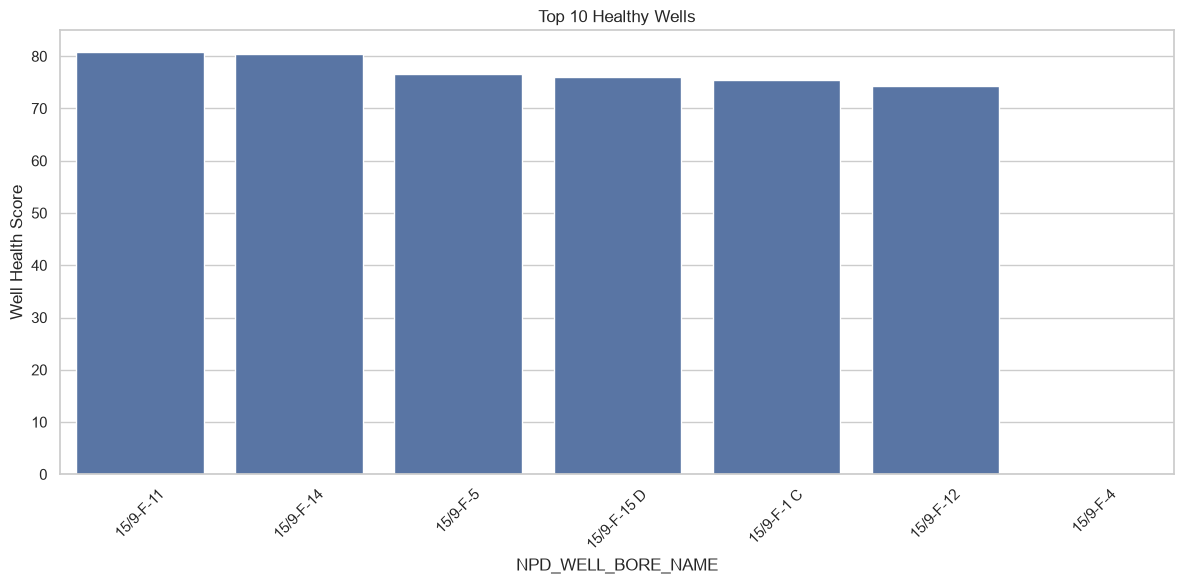

In [28]:
# ==========================================
# Top Healthy Wells
# ==========================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=best_wells.head(10).reset_index(),

    x="NPD_WELL_BORE_NAME",

    y="Well Health Score"

)

plt.xticks(rotation=45)

plt.title("Top 10 Healthy Wells")

plt.tight_layout()

plt.show()

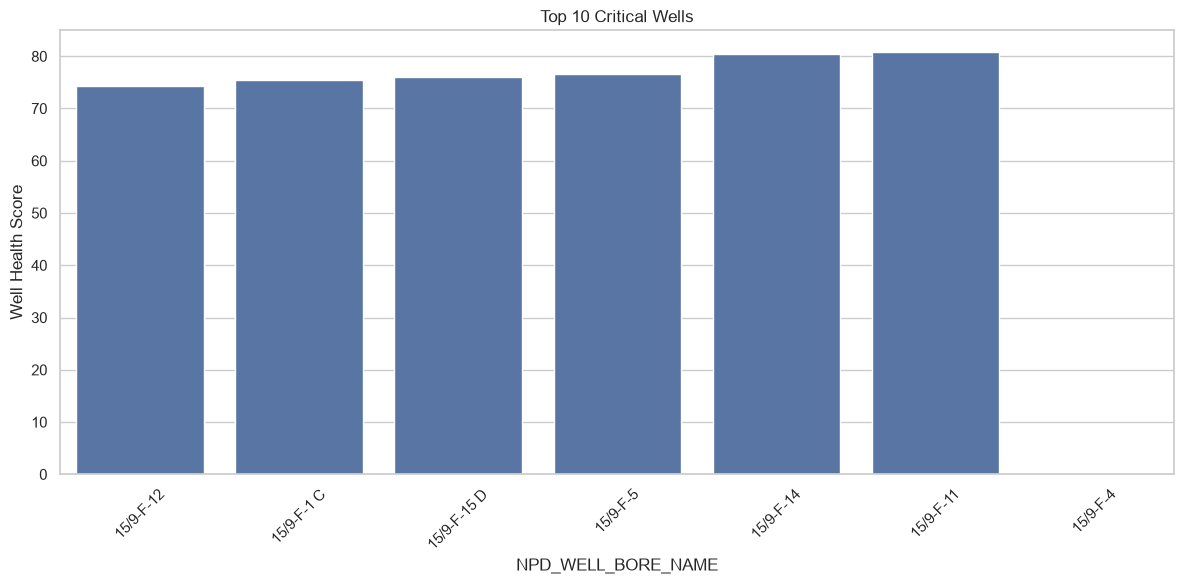

In [29]:
# ==========================================
# Top Critical Wells
# ==========================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=risk_wells.head(10).reset_index(),

    x="NPD_WELL_BORE_NAME",

    y="Well Health Score"

)

plt.xticks(rotation=45)

plt.title("Top 10 Critical Wells")

plt.tight_layout()

plt.show()

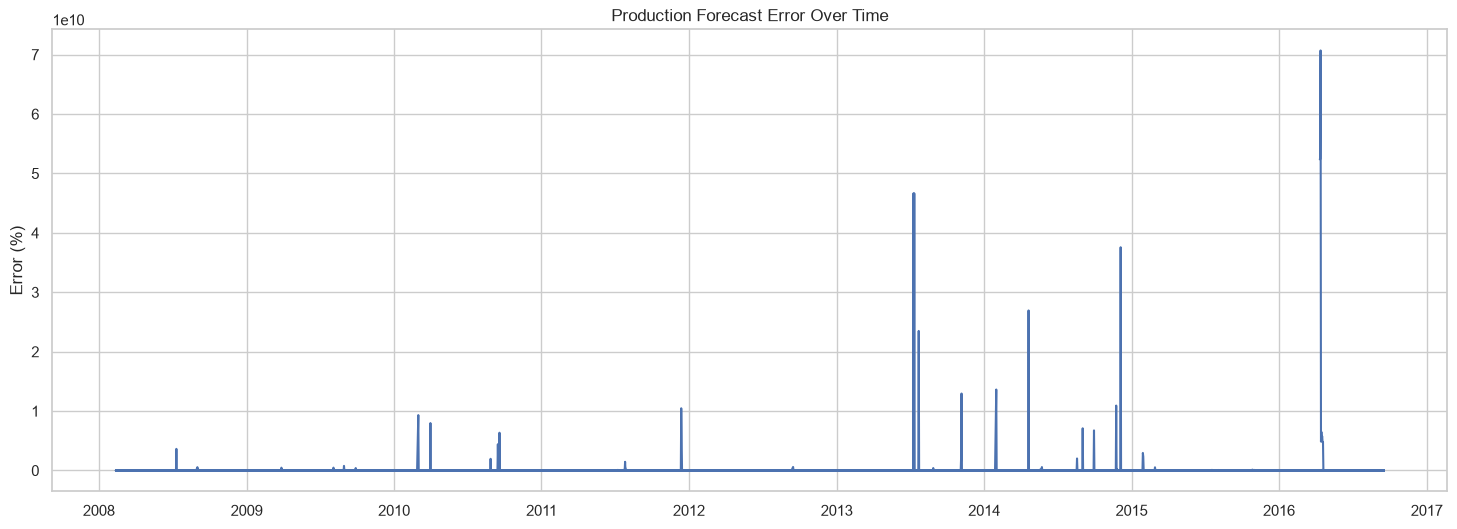

In [30]:
# ==========================================
# Production Error Trend
# ==========================================

plt.figure(figsize=(18,6))

plt.plot(

    df["DATEPRD"],

    df["Production Error (%)"]

)

plt.title("Production Forecast Error Over Time")

plt.ylabel("Error (%)")

plt.grid(True)

plt.show()

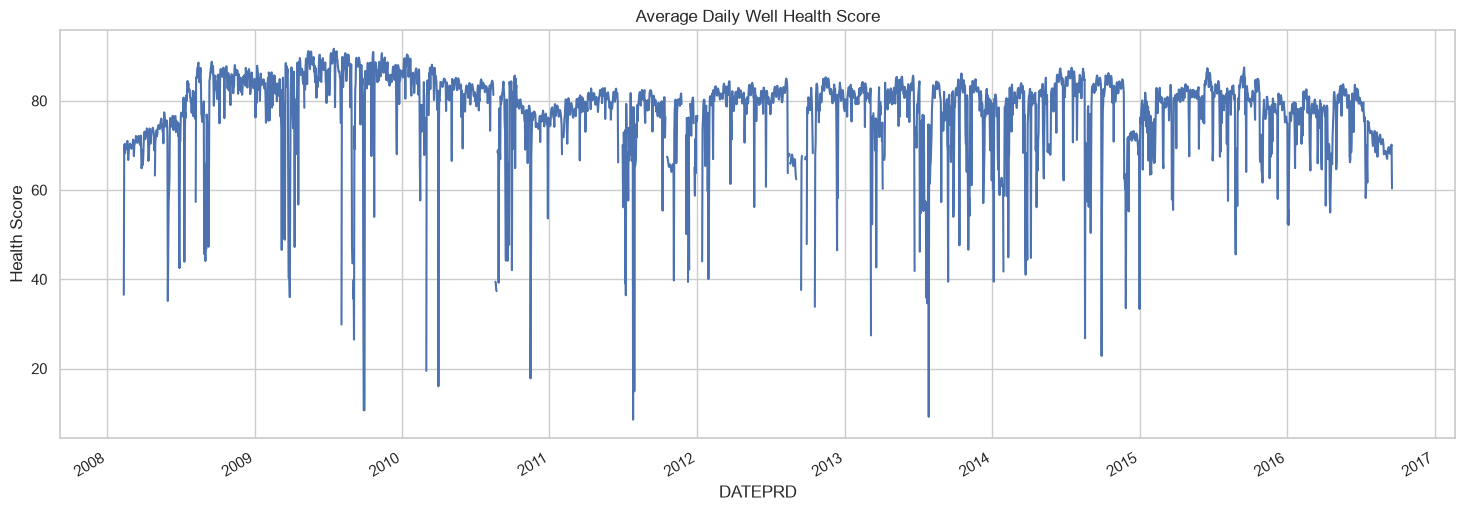

In [31]:
# ==========================================
# Well Health Trend
# ==========================================

daily_health = (

    df.groupby("DATEPRD")

    ["Well Health Score"]

    .mean()

)

plt.figure(figsize=(18,6))

daily_health.plot()

plt.title("Average Daily Well Health Score")

plt.ylabel("Health Score")

plt.grid(True)

plt.show()

In [32]:
# ==========================================
# Recommendation Summary
# ==========================================

recommendations = (

    df["Recommendation"]

    .value_counts()

)

recommendations

Recommendation
Immediate inspection recommended. Check tubing, pressure sensors and production equipment.    6813
Increase monitoring frequency.                                                                5599
Continue normal operation.                                                                    2200
Inspect pressure system and choke settings.                                                   1022
Name: count, dtype: int64

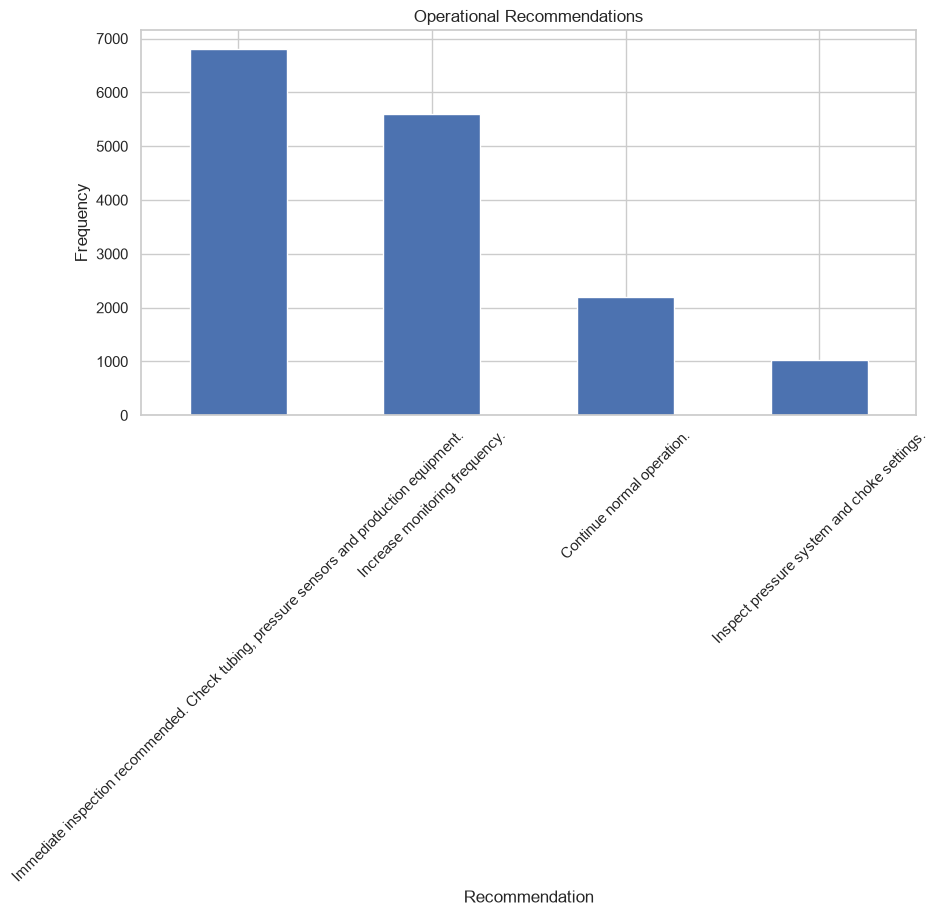

In [35]:
# ==========================================
# Recommendation Distribution
# ==========================================

plt.figure(figsize=(10,5))

recommendations.plot(

    kind="bar"

)

plt.title("Operational Recommendations")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [36]:
# ==========================================
# Export Reports
# ==========================================

best_wells.to_csv(

    "Healthy_Wells.csv"

)

risk_wells.to_csv(

    "Critical_Wells.csv"

)

well_summary.to_csv(

    "Executive_Summary.csv"

)

print("Reports Exported Successfully.")

Reports Exported Successfully.


In [37]:
# ==========================================
# IntelliWell Final Report
# ==========================================

print("="*70)
print("          INTELLIWELL FINAL REPORT")
print("="*70)

print("Production Forecast Model")
print("Random Forest Regressor")

print("\nPressure Model")
print("Isolation Forest")

print("\nAverage Well Health Score")

print(f"{avg_health:.2f}")

print("\nPressure Anomalies")

print(pressure_anomalies)

print("\nHealthy Wells")

print(healthy)

print("\nCritical Wells")

print(critical)

print("\nGenerated Files")

print("- IntelliWell_Final_Report.csv")

print("- Healthy_Wells.csv")

print("- Critical_Wells.csv")

print("- Executive_Summary.csv")

print("="*70)

print("Decision Support System Completed Successfully.")

print("="*70)

          INTELLIWELL FINAL REPORT
Production Forecast Model
Random Forest Regressor

Pressure Model
Isolation Forest

Average Well Health Score
77.47

Pressure Anomalies
313

Healthy Wells
2200

Critical Wells
6813

Generated Files
- IntelliWell_Final_Report.csv
- Healthy_Wells.csv
- Critical_Wells.csv
- Executive_Summary.csv
Decision Support System Completed Successfully.
